plot the q factor with frequency, and each data point represent a group of voltage values (solid line is mean and shaded region is min and max). 

In [22]:
%load_ext autoreload
%autoreload 2

import h5py
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import skrf as rf
import sys
sys.path.append('../src/')
from rf_functions.rf_calculation import CapacitorAnalysis
from rf_functions.rf_figures import FigureGenerator
from rf_functions.utils import save_dict_to_hdf5, load_dict_from_hdf5, group_frequencies
from rf_functions.qfactor_frequency_stat import process_qfactor_frequency, viz_qfactor_frequency

from m3util.viz.style import set_style
set_style('printing')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
printing set for seaborn


## viz figures

In [23]:
# Load the entire Excel file
file_path = "../datasets/Q data-updated.xlsx"  # or "data.xlsx"
xls = pd.ExcelFile(file_path)

# Get sheet names
sheet_names = xls.sheet_names
print(sheet_names)  # List of sheet names


['LYW089 0degree', 'LYW034 0degree', 'LYW033 0degree', 'LYW032 0degree', 'LYW035 0degree']


LYW089 0degree


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  Unnamed: 0  Unnamed: 1  Bias Voltage  Unnamed: 3  Unnamed: 4   Unnamed: 5  \
0        NaN         NaN   -200.000000 -198.000000 -196.000000  -194.000000   
1  Frequency    0.010000     11.753420   19.990642    2.431738     9.432642   
2        NaN    0.019996     15.330111   13.009253   11.493250  1016.980892   
3        NaN    0.029992    231.773987   15.311349   16.767137   113.513621   
4        NaN    0.039989     23.752437   74.697569   59.750677    64.253970   

   Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  ...  Unnamed: 193  \
0 -192.000000 -190.000000 -188.000000 -186.000000  ...    182.000000   
1    0.276726    2.231152   20.295016    3.349224  ...      1.384910   
2   38.182512   10.588153   59.493006   51.693444  ...     18.073407   
3   60.354200  241.598786   39.747647   24.855974  ...    108.043476   
4   21.809713   63.690884  123.242491  170.290534  ...     83.300102   

   Unnamed: 194  Unnamed: 195  Unnamed: 196  Unnamed: 197  Unnamed: 198  \
0    184.000000  

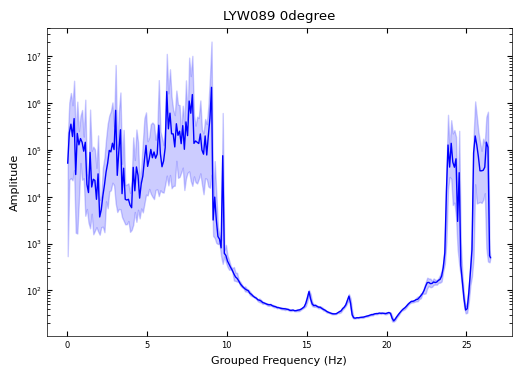

LYW034 0degree


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  Unnamed: 0  Unnamed: 1  Bias Voltage  Unnamed: 3   Unnamed: 4  Unnamed: 5  \
0        NaN         NaN   -200.000000 -198.000000  -196.000000 -194.000000   
1  Frequency    0.010000      3.259556    0.824290     1.404930    0.540673   
2        NaN    0.019996     13.157106   86.480295     5.076925    8.577468   
3        NaN    0.029992     28.294031    8.193141  1008.628603   17.448036   
4        NaN    0.039989     24.064439   92.949813    77.445753   66.018212   

   Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  ...  Unnamed: 193  \
0 -192.000000 -190.000000 -188.000000 -186.000000  ...    182.000000   
1    5.318364    2.924135    6.057416    0.542891  ...      2.971652   
2   10.617541    6.386901   48.420473    6.388597  ...      7.808777   
3   23.755487   30.223888   23.833936  110.716423  ...    130.999780   
4   28.861912  141.365220   21.540786  343.225041  ...    456.999118   

   Unnamed: 194  Unnamed: 195  Unnamed: 196  Unnamed: 197  Unnamed: 198  \
0    184.000000  

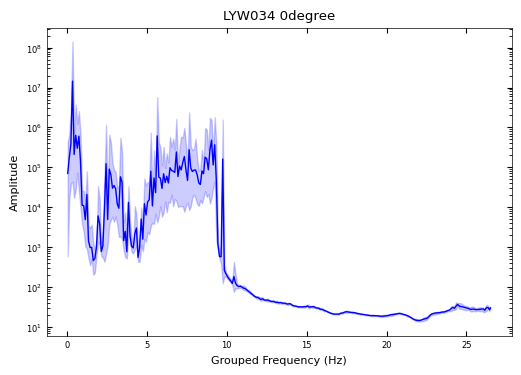

LYW033 0degree


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  Unnamed: 0  Unnamed: 1  Bias Voltage  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0        NaN         NaN   -200.000000 -198.000000 -196.000000 -194.000000   
1  Frequency    0.010000      1.112074    2.411193   17.003506    4.832501   
2        NaN    0.019996      5.849109   12.772882    6.453292   13.628167   
3        NaN    0.029992     53.692246  101.088154   20.495308  100.996759   
4        NaN    0.039989    102.568878   20.335130   74.124247   30.758268   

   Unnamed: 6   Unnamed: 7  Unnamed: 8  Unnamed: 9  ...  Unnamed: 193  \
0 -192.000000  -190.000000 -188.000000 -186.000000  ...    182.000000   
1    9.482442     0.965485   15.840137    4.964578  ...      2.246492   
2   12.467400  2084.553603    6.478260   31.630228  ...     21.496539   
3  437.192583    30.720674  145.791446   39.398317  ...     60.637849   
4   28.809753    44.442653  239.609771  151.751068  ...     87.468533   

   Unnamed: 194  Unnamed: 195  Unnamed: 196  Unnamed: 197  Unnamed: 198  \
0    184.000000  

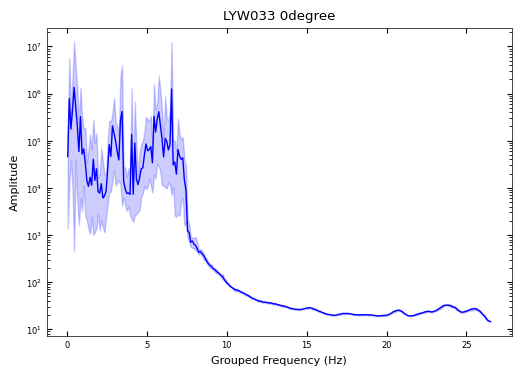

LYW032 0degree


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  Unnamed: 0  Unnamed: 1  Bias Voltage  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0        NaN         NaN   -200.000000 -198.000000 -196.000000 -194.000000   
1  Frequency    0.010000      1.372589    0.495840    3.380020    3.910602   
2        NaN    0.019996      7.101994   21.634268   16.725479   21.495736   
3        NaN    0.029992     35.008141   89.161123   18.253834  168.373146   
4        NaN    0.039989    243.778844  193.063553   49.482922   57.064515   

   Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  ...  Unnamed: 193  \
0 -192.000000 -190.000000 -188.000000 -186.000000  ...    182.000000   
1    4.412795   12.268777   23.692033    1.617679  ...      4.292246   
2   11.171730   18.924192   38.706755   36.991168  ...      6.540453   
3   74.639893   60.091448  136.805805   89.449882  ...   1270.565068   
4   59.111084  201.661167   40.777580   55.328659  ...     53.613416   

   Unnamed: 194  Unnamed: 195  Unnamed: 196  Unnamed: 197  Unnamed: 198  \
0    184.000000    186.

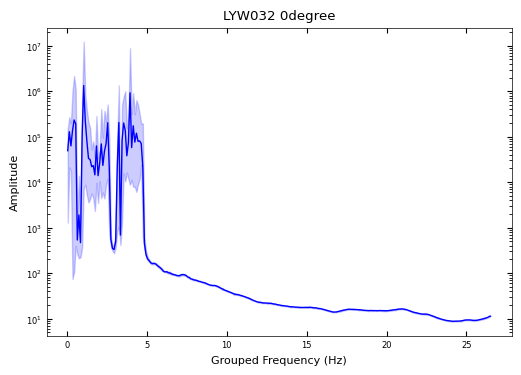

LYW035 0degree


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  Unnamed: 0  Unnamed: 1  Bias Voltage  Unnamed: 3  Unnamed: 4   Unnamed: 5  \
0        NaN         NaN   -200.000000 -198.000000 -196.000000  -194.000000   
1  Frequency    0.010000      1.009640   10.298787    9.349920     2.021101   
2        NaN    0.019996      6.399116   15.816469  311.214144   181.244130   
3        NaN    0.029992     77.300740   78.118717  292.539756    45.858192   
4        NaN    0.039989    167.982523   35.855452  132.886227  1728.268421   

   Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  ...  Unnamed: 193  \
0 -192.000000 -190.000000 -188.000000 -186.000000  ...    182.000000   
1    4.564540   79.750322    0.743105    1.523032  ...      7.469908   
2    4.453101   10.035695   11.935619    8.697661  ...     20.662870   
3   70.803090   42.154002   46.848466  108.143528  ...     61.203621   
4   47.936448  436.801344   91.682357   80.588616  ...     49.546721   

   Unnamed: 194  Unnamed: 195  Unnamed: 196  Unnamed: 197  Unnamed: 198  \
0    184.000000  

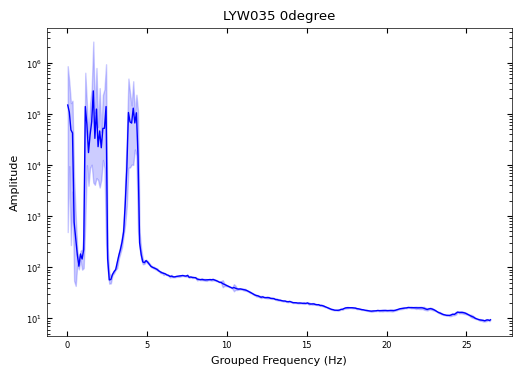

In [24]:
for sample_name in sheet_names:
    print(sample_name)
    df = pd.read_excel(file_path, sheet_name=sample_name)
    print(df.head(5))

    frequency = np.array(df.iloc[1:, 1].values).astype(float)
    voltage = np.array(df.iloc[0, 2:].values).astype(float)
    qfactor = df.iloc[1:, 2:].values.astype(float)
    print(frequency.shape, voltage.shape,  qfactor.shape)

    qfactor_all = pd.DataFrame(qfactor, index=frequency, columns=voltage)
    print(qfactor_all.head(5))

    qfactor_all_max_grouped = process_qfactor_frequency(qfactor_all, group_size=10)
    viz_qfactor_frequency(qfactor_all_max_grouped, title=sample_name, filename=f'../output/{sample_name}-0.1V')

In [6]:
print(sheet_names[0])
df = pd.read_excel(file_path, sheet_name=sheet_names[0])
df

LYW089 0degree


,Unnamed: 0,Unnamed: 1,Bias Voltage,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 193,Unnamed: 194,Unnamed: 195,Unnamed: 196,Unnamed: 197,Unnamed: 198,Unnamed: 199,Unnamed: 200,Unnamed: 201,Unnamed: 202
0,NaN,NaN,-200.000000,-198.000000,-196.000000,-194.000000,-192.000000,-190.000000,-188.000000,-186.000000,...,182.000000,184.000000,186.000000,188.000000,190.000000,192.000000,194.000000,196.000000,198.000000,200.000000
1,Frequency,0.010000,11.753420,19.990642,2.431738,9.432642,0.276726,2.231152,20.295016,3.349224,...,1.384910,3.617821,18.345446,1.027328,6.628420,1.084751,5.228963,1.335555,2.710104,8.975284
2,NaN,0.019996,15.330111,13.009253,11.493250,1016.980892,38.182512,10.588153,59.493006,51.693444,...,18.073407,136.268894,9.114237,14.842717,23.330409,8.137284,29.907905,14.828234,30.541837,12.046955
3,NaN,0.029992,231.773987,15.311349,16.767137,113.513621,60.354200,241.598786,39.747647,24.855974,...,108.043476,35.634259,25.405152,67.835575,77.360273,26.124639,25.683285,29.188250,93.440078,29.354926
4,NaN,0.039989,23.752437,74.697569,59.750677,64.253970,21.809713,63.690884,123.242491,170.290534,...,83.300102,28.838951,406.661346,32.237800,106.173200,238.151017,61.606490,59.515480,193.938371,66.593826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2647,NaN,26.460015,397.384743,374.874241,370.918344,350.109819,327.550176,337.263209,337.607950,318.699847,...,294.506819,290.711244,326.981342,316.863513,336.167801,350.502097,336.439757,352.373637,353.251514,384.214994
2648,NaN,26.470011,424.894510,409.659635,414.250407,362.088495,368.443366,362.267325,340.736612,341.768827,...,314.676404,316.743824,350.765835,346.608091,369.278276,365.804489,363.165165,369.940346,386.788055,417.230870
2649,NaN,26.480008,487.520159,465.607946,435.944706,399.163029,386.125586,398.666794,365.479056,354.200118,...,338.213776,332.007109,387.158084,364.179698,407.275033,409.609528,391.978874,407.062802,432.391300,454.788071
2650,NaN,26.490004,596.804628,525.888353,525.598396,492.669071,433.143298,448.243504,432.760413,434.271839,...,367.332413,393.429603,440.022954,419.230705,461.681416,467.497836,458.675358,485.837499,492.055369,580.743084


In [4]:
frequency = np.array(df.iloc[1:, 1].values).astype(float)
voltage = np.array(df.iloc[0, 2:].values).astype(float)
qfactor = df.iloc[1:, 2:].values.astype(float)
print(frequency.shape, voltage.shape,  qfactor.shape)

qfactor_all = pd.DataFrame(qfactor, index=frequency, columns=voltage)
qfactor_all

(2651,) (201,) (2651, 201)


,-200.0,-198.0,-196.0,-194.0,-192.0,-190.0,-188.0,-186.0,-184.0,-182.0,...,182.0,184.0,186.0,188.0,190.0,192.0,194.0,196.0,198.0,200.0
0.010000,11.753420,19.990642,2.431738,9.432642,0.276726,2.231152,20.295016,3.349224,1.799271,0.933119,...,1.384910,3.617821,18.345446,1.027328,6.628420,1.084751,5.228963,1.335555,2.710104,8.975284
0.019996,15.330111,13.009253,11.493250,1016.980892,38.182512,10.588153,59.493006,51.693444,9.815863,46.681181,...,18.073407,136.268894,9.114237,14.842717,23.330409,8.137284,29.907905,14.828234,30.541837,12.046955
0.029992,231.773987,15.311349,16.767137,113.513621,60.354200,241.598786,39.747647,24.855974,64.526101,250.385483,...,108.043476,35.634259,25.405152,67.835575,77.360273,26.124639,25.683285,29.188250,93.440078,29.354926
0.039989,23.752437,74.697569,59.750677,64.253970,21.809713,63.690884,123.242491,170.290534,112.993920,94.076523,...,83.300102,28.838951,406.661346,32.237800,106.173200,238.151017,61.606490,59.515480,193.938371,66.593826
0.049985,334.603684,90.477549,5522.613369,3281.578185,841.149562,639.694476,301.633201,582.783534,152.505928,120.270526,...,155.666405,1071.149297,275.220156,43.498973,50.456505,109.395075,486.833380,43.901121,113.780103,3037.230880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26.460015,397.384743,374.874241,370.918344,350.109819,327.550176,337.263209,337.607950,318.699847,315.142329,288.350230,...,294.506819,290.711244,326.981342,316.863513,336.167801,350.502097,336.439757,352.373637,353.251514,384.214994
26.470011,424.894510,409.659635,414.250407,362.088495,368.443366,362.267325,340.736612,341.768827,344.780831,314.796697,...,314.676404,316.743824,350.765835,346.608091,369.278276,365.804489,363.165165,369.940346,386.788055,417.230870
26.480008,487.520159,465.607946,435.944706,399.163029,386.125586,398.666794,365.479056,354.200118,362.692961,342.715083,...,338.213776,332.007109,387.158084,364.179698,407.275033,409.609528,391.978874,407.062802,432.391300,454.788071
26.490004,596.804628,525.888353,525.598396,492.669071,433.143298,448.243504,432.760413,434.271839,419.910613,384.591158,...,367.332413,393.429603,440.022954,419.230705,461.681416,467.497836,458.675358,485.837499,492.055369,580.743084


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


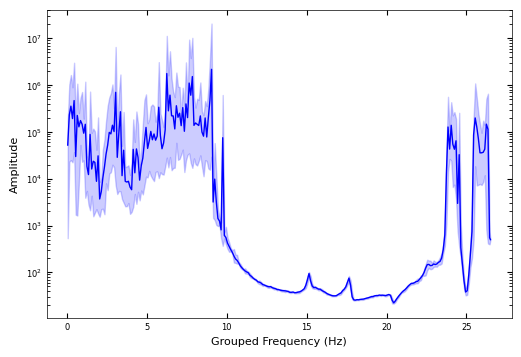

In [5]:
viz_qfactor_frequency(qfactor_all, group_size=10, filename='../output/qfactor_vs_frequency-0.1V')

In [ ]:
viz_qfactor_frequency(qfactor_all, group_size=10, filename='../output/qfactor_vs_frequency-0.1V')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


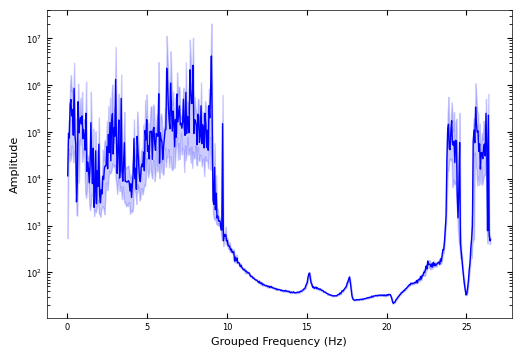

In [18]:
# Compute the max Q-factor across voltages
qfactor_all_max = pd.DataFrame(qfactor_all.max(axis=1), columns=['Q-factor'])
qfactor_all_max_grouped = group_frequencies(qfactor_all_max, group_size=5)
# qfactor_all_max_grouped_long = qfactor_all_max_grouped.reset_index().melt(value_name="Q-factor")
qfactor_all_max_grouped

qfactor_all_max_grouped = qfactor_all_max_grouped.reset_index()
qfactor_all_max_grouped.columns = ["Frequency", "Q-factor"]
qfactor_all_max_grouped

# Compute min/max manually
df_min = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].min()
df_max = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].max()
df_mean = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].mean()

plt.figure(figsize=(6, 4))

# Plot mean line
sns.lineplot(x=df_mean.index, y=df_mean.values, color='b', linewidth=1)

# Fill between min/max values
plt.fill_between(df_mean.index, df_min.values, df_max.values, color='b', alpha=0.2)

plt.xlabel("Grouped Frequency (Hz)")
plt.ylabel("Amplitude")
plt.yscale("log")
plt.legend()
plt.savefig("../output/qfactor_vs_frequency-0.05V.png")
plt.savefig("../output/qfactor_vs_frequency-0.05V.svg")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


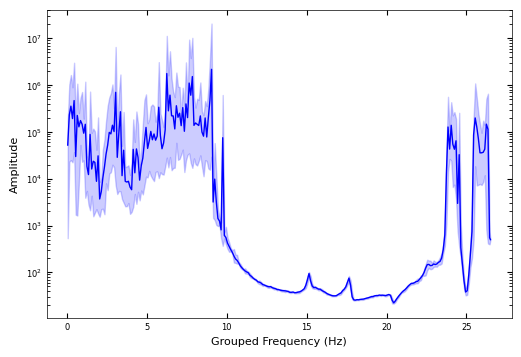

In [17]:
# Compute the max Q-factor across voltages
qfactor_all_max = pd.DataFrame(qfactor_all.max(axis=1), columns=['Q-factor'])
qfactor_all_max_grouped = group_frequencies(qfactor_all_max, group_size=10)
# qfactor_all_max_grouped_long = qfactor_all_max_grouped.reset_index().melt(value_name="Q-factor")
qfactor_all_max_grouped

qfactor_all_max_grouped = qfactor_all_max_grouped.reset_index()
qfactor_all_max_grouped.columns = ["Frequency", "Q-factor"]
qfactor_all_max_grouped

# Compute min/max manually
df_min = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].min()
df_max = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].max()
df_mean = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].mean()

plt.figure(figsize=(6, 4))

# Plot mean line
sns.lineplot(x=df_mean.index, y=df_mean.values, color='b', linewidth=1)

# Fill between min/max values
plt.fill_between(df_mean.index, df_min.values, df_max.values, color='b', alpha=0.2)

plt.xlabel("Grouped Frequency (Hz)")
plt.ylabel("Amplitude")
plt.yscale("log")
plt.legend()
plt.savefig("../output/qfactor_vs_frequency-0.1V.png")
plt.savefig("../output/qfactor_vs_frequency-0.1V.svg")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


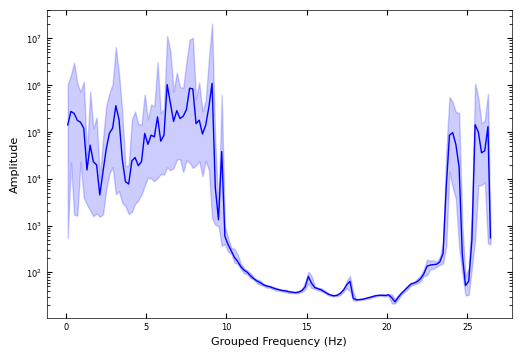

In [16]:
# Compute the max Q-factor across voltages
qfactor_all_max = pd.DataFrame(qfactor_all.max(axis=1), columns=['Q-factor'])
qfactor_all_max_grouped = group_frequencies(qfactor_all_max, group_size=20)
# qfactor_all_max_grouped_long = qfactor_all_max_grouped.reset_index().melt(value_name="Q-factor")
qfactor_all_max_grouped

qfactor_all_max_grouped = qfactor_all_max_grouped.reset_index()
qfactor_all_max_grouped.columns = ["Frequency", "Q-factor"]
qfactor_all_max_grouped

# Compute min/max manually
df_min = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].min()
df_max = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].max()
df_mean = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].mean()

plt.figure(figsize=(6, 4))

# Plot mean line
sns.lineplot(x=df_mean.index, y=df_mean.values, color='b', linewidth=1)

# Fill between min/max values
plt.fill_between(df_mean.index, df_min.values, df_max.values, color='b', alpha=0.2)

plt.xlabel("Grouped Frequency (Hz)")
plt.ylabel("Amplitude")
plt.yscale("log")
plt.legend()
plt.savefig("../output/qfactor_vs_frequency-0.2V.png")
plt.savefig("../output/qfactor_vs_frequency-0.2V.svg")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


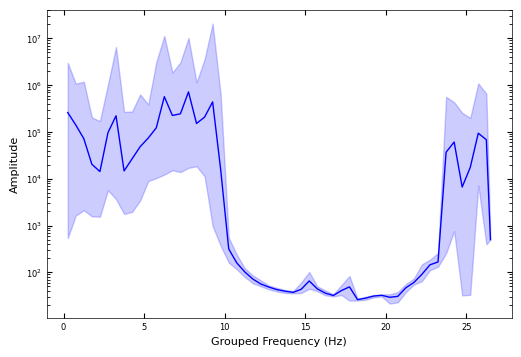

In [14]:
# Compute the max Q-factor across voltages
qfactor_all_max = pd.DataFrame(qfactor_all.max(axis=1), columns=['Q-factor'])
qfactor_all_max_grouped = group_frequencies(qfactor_all_max, group_size=50)
# qfactor_all_max_grouped_long = qfactor_all_max_grouped.reset_index().melt(value_name="Q-factor")
qfactor_all_max_grouped

qfactor_all_max_grouped = qfactor_all_max_grouped.reset_index()
qfactor_all_max_grouped.columns = ["Frequency", "Q-factor"]
qfactor_all_max_grouped

# Compute min/max manually
df_min = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].min()
df_max = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].max()
df_mean = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].mean()

plt.figure(figsize=(6, 4))

# Plot mean line
sns.lineplot(x=df_mean.index, y=df_mean.values, color='b', linewidth=1)

# Fill between min/max values
plt.fill_between(df_mean.index, df_min.values, df_max.values, color='b', alpha=0.2)

plt.xlabel("Grouped Frequency (Hz)")
plt.ylabel("Amplitude")
plt.yscale("log")
plt.legend()
plt.savefig("../output/qfactor_vs_frequency-0.5V.png")
plt.savefig("../output/qfactor_vs_frequency-0.5V.svg")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


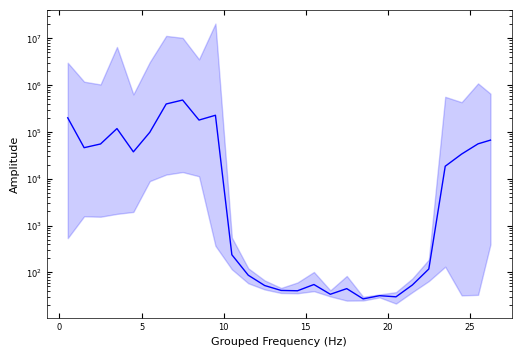

In [15]:
# Compute the max Q-factor across voltages
qfactor_all_max = pd.DataFrame(qfactor_all.max(axis=1), columns=['Q-factor'])
qfactor_all_max_grouped = group_frequencies(qfactor_all_max, group_size=100)
# qfactor_all_max_grouped_long = qfactor_all_max_grouped.reset_index().melt(value_name="Q-factor")
qfactor_all_max_grouped

qfactor_all_max_grouped = qfactor_all_max_grouped.reset_index()
qfactor_all_max_grouped.columns = ["Frequency", "Q-factor"]
qfactor_all_max_grouped

# Compute min/max manually
df_min = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].min()
df_max = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].max()
df_mean = qfactor_all_max_grouped.groupby("Frequency")["Q-factor"].mean()

plt.figure(figsize=(6, 4))

# Plot mean line
sns.lineplot(x=df_mean.index, y=df_mean.values, color='b', linewidth=1)

# Fill between min/max values
plt.fill_between(df_mean.index, df_min.values, df_max.values, color='b', alpha=0.2)

plt.xlabel("Grouped Frequency (Hz)")
plt.ylabel("Amplitude")
plt.yscale("log")
plt.legend()
plt.savefig("../output/qfactor_vs_frequency-1V.png")
plt.savefig("../output/qfactor_vs_frequency-1V.svg")
plt.show()